In [1]:
import os

# Specify the path to your images folder in Google Drive
image_folder_path = '/content/drive/MyDrive/images'

# List the contents of the folder
try:
    files_in_folder = os.listdir(image_folder_path)
    print(f"Files in {image_folder_path}:")
    for item in files_in_folder:
        print(item)
except FileNotFoundError:
    print(f"Error: The folder '{image_folder_path}' was not found. Please ensure the path is correct and your Drive is mounted.")
except Exception as e:
    print(f"An error occurred: {e}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 35.9 MB/s eta 0:00:00


In [3]:
import os
import numpy as np
import faiss
from PIL import Image
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer

In [4]:
model = SentenceTransformer("clip-ViT-B-32")
print("Model Loaded Successfully")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: /root/.cache/huggingface/hub/models--sentence-transformers--clip-ViT-B-32/snapshots/327ab6726d33c0e22f920c83f2ff9e4bd38ca37f/0_CLIPModel
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Model Loaded Successfully


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import requests

os.makedirs("images", exist_ok=True)

urls = [
    "https://images.unsplash.com/photo-1518717758536-85ae29035b6d",  # dog
    "https://images.unsplash.com/photo-1503023345310-bd7c1de61c7d",  # cat
    "https://images.unsplash.com/photo-1507149833265-60c372daea22",  # puppy
    "https://images.unsplash.com/photo-1492724441997-5dc865305da7",  # nature
    "https://images.unsplash.com/photo-1500530855697-b586d89ba3ee"   # mountain
]

image_paths = []

for i, url in enumerate(urls):
    response = requests.get(url)
    path = f"images/img_{i}.jpg"

    with open(path, "wb") as f:
        f.write(response.content)

    image_paths.append(path)

print("Downloaded Images:", len(image_paths))

Downloaded Images: 5


In [7]:
embeddings = []

for path in image_paths:
    image = Image.open(path)
    emb = model.encode(image)
    embeddings.append(emb)

embeddings = np.array(embeddings)

print("Embedding Shape:", embeddings.shape)

Embedding Shape: (5, 512)


In [8]:
dimension = embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)
index.add(embeddings)

print("Total vectors in index:", index.ntotal)

Total vectors in index: 5


In [9]:
def search_images(query, top_k=3):
    query_embedding = model.encode([query])

    distances, indices = index.search(
        np.array(query_embedding), top_k
    )

    return indices[0]

In [10]:
query = "dog"
results = search_images(query)

print("Results:", results)

Results: [0 4 2]


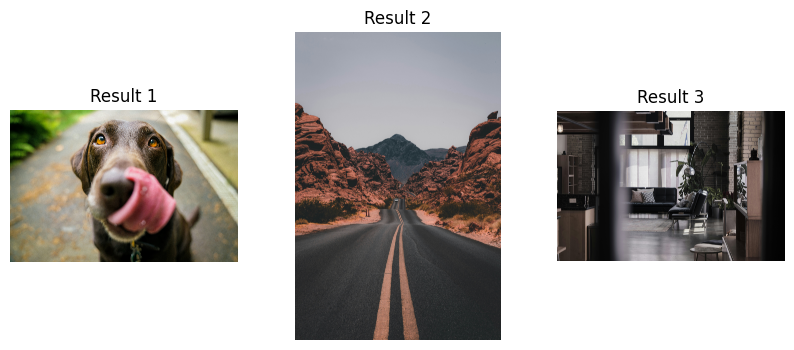

In [11]:
plt.figure(figsize=(10,4))

for i, idx in enumerate(results):
    img = Image.open(image_paths[idx])

    plt.subplot(1,3,i+1)
    plt.imshow(img)
    plt.title(f"Result {i+1}")
    plt.axis("off")

plt.show()

In [12]:
def generate_explanation(query):
    explanation = f"The retrieved images match the query '{query}' because the visual features are similar."

    return explanation

print(generate_explanation(query))

The retrieved images match the query 'dog' because the visual features are similar.
